In [17]:
import os
import cv2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
os.chdir('/app')
from configs import base_config

%matplotlib inline

In [11]:
config = base_config.BaseConfig()

In [13]:
train_paths = [config.train_dir + train_path for train_path in os.listdir(config.train_dir)]

In [46]:
secelt_n = 0
cap = cv2.VideoCapture(train_paths[secelt_n])
ret, img = cap.read()
print(img.shape)
print(cap.get(cv2.CAP_PROP_FPS))
print(cap.get(cv2.CAP_PROP_FRAME_COUNT))

(360, 640, 3)
30.0
485.0


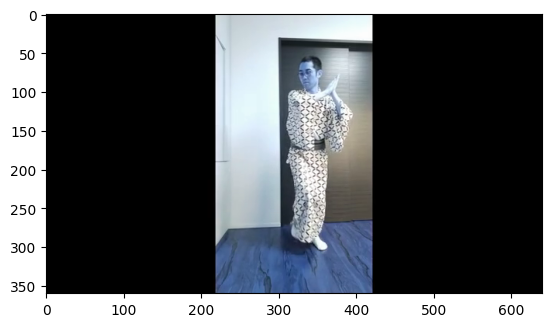

In [47]:
plt.imshow(img)

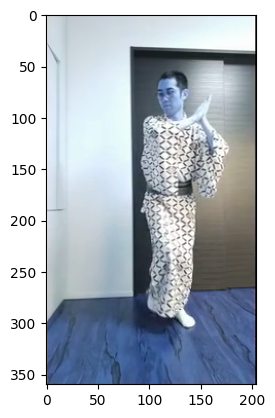

In [48]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, threshold = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)

contours, _ = cv2.findContours(threshold, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(contours, key=cv2.contourArea)
x, y, w, h = cv2.boundingRect(largest_contour)

cropped_image = img[y:y+h, x:x+w]

plt.imshow(cropped_image)

In [49]:
from utils import image_processor
images = image_processor.load_image(train_paths[0])
image_processor.save_video(images, config.output_dir+'tmp.mp4')

In [50]:
cap = cv2.VideoCapture(config.output_dir+'tmp.mp4')
ret, img = cap.read()

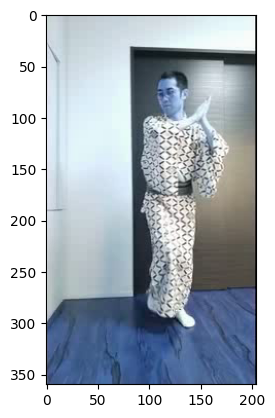

In [51]:
plt.imshow(img)